# 04 — Null Recovery Audit

**Purpose**: Verify that `scripts/impute_features.py` correctly recovered the 5 quarterly features and `size_category`.
Compare null counts before/after and inspect imputation quality.

Prerequisites:
- `data/historical_dataset_clean.parquet` — 341-column post-imputation dataset
- `data/historical_dataset.parquet` — pre-clean parquet (with quarterly rows)

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

clean_path = ROOT / 'data' / 'historical_dataset_clean.parquet'
df_clean = pd.read_parquet(clean_path)
annual = df_clean[df_clean['period_type'] == 'annual'].copy()

print(f'Total rows: {len(df_clean):,}')
print(f'Annual rows: {len(annual):,}')
print(f'Columns: {df_clean.shape[1]}')

Total rows: 58,190
Annual rows: 58,190
Columns: 346


## 1 — Quarterly feature null rates (post-imputation)

In [2]:
QUARTERLY_COLS = [
    'revenue_qoq_std_norm',
    'earnings_qoq_mean',
    'max_accruals_ttm',
    'revenue_acceleration',
    'quarterly_positive_rev_frac',
]

print('Quarterly feature coverage in annual rows:')
for col in QUARTERLY_COLS:
    if col in annual.columns:
        n_notna = annual[col].notna().sum()
        print(f'  {col:<40} {n_notna:>7,}  ({n_notna/len(annual)*100:.1f}% filled)')
    else:
        print(f'  {col:<40} MISSING — column not found')

Quarterly feature coverage in annual rows:
  revenue_qoq_std_norm                      38,969  (67.0% filled)
  earnings_qoq_mean                         35,803  (61.5% filled)
  max_accruals_ttm                          38,979  (67.0% filled)
  revenue_acceleration                      35,590  (61.2% filled)
  quarterly_positive_rev_frac               38,979  (67.0% filled)


## 2 — size_category imputation quality

size_category distribution (post-imputation):
size_category
0.0    20349
1.0    13586
2.0    12112
3.0    11070
NaN     1073
Name: count, dtype: int64

Remaining nulls: 1,073  (1.84%)
Rows imputed (size_category_imputed=True): 17,109  (29.4%)


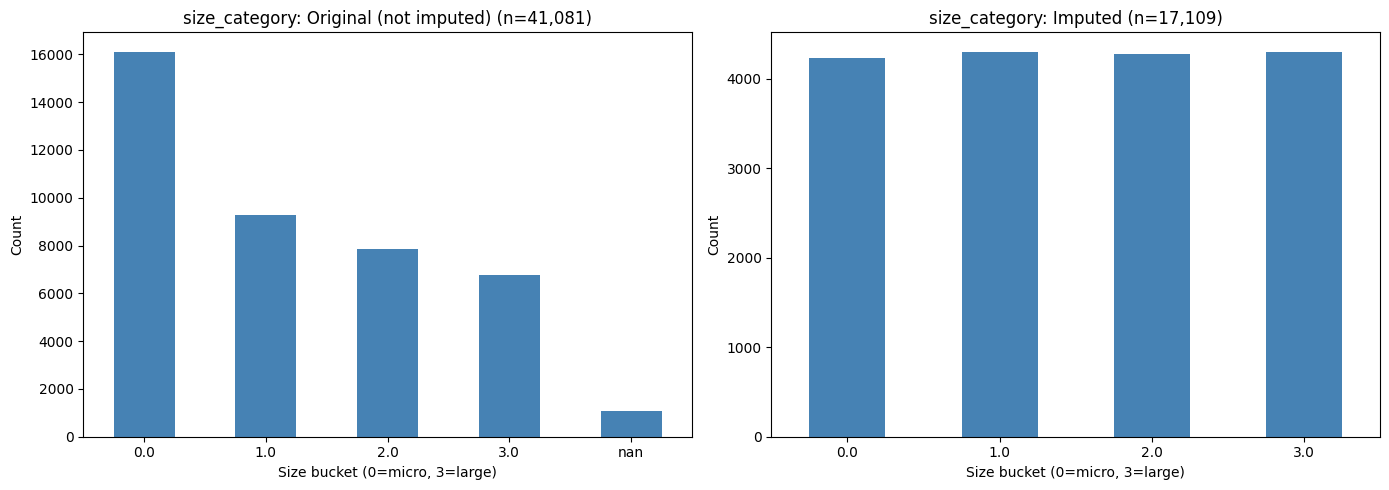

In [3]:
if 'size_category' in annual.columns:
    print('size_category distribution (post-imputation):')
    print(annual['size_category'].value_counts(dropna=False).sort_index())
    
    null_remaining = annual['size_category'].isna().sum()
    print(f'\nRemaining nulls: {null_remaining:,}  ({null_remaining/len(annual)*100:.2f}%)')
    
    if 'size_category_imputed' in annual.columns:
        n_imp = annual['size_category_imputed'].sum()
        print(f'Rows imputed (size_category_imputed=True): {n_imp:,}  ({n_imp/len(annual)*100:.1f}%)')

        # Imputed vs original distribution
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax, (label, mask) in zip(axes, [
            ('Original (not imputed)', ~annual['size_category_imputed'].fillna(False)),
            ('Imputed', annual['size_category_imputed'].fillna(False)),
        ]):
            sub = annual[mask]['size_category'].value_counts(dropna=False).sort_index()
            sub.plot(kind='bar', ax=ax, color='steelblue')
            ax.set_title(f'size_category: {label} (n={mask.sum():,})')
            ax.set_xlabel('Size bucket (0=micro, 3=large)')
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=0)
        plt.tight_layout()
        plt.show()

## 3 — Quarterly feature coverage by market

Quarterly feature fill rate by market:
        revenue_qoq_std_norm  earnings_qoq_mean  max_accruals_ttm  revenue_acceleration  quarterly_positive_rev_frac
market                                                                                                              
BR                  0.917151           0.931686          0.931686              0.000000                     0.931686
CA                  0.000000           0.000000          0.000000              0.000000                     0.000000
DE                  0.000000           0.000000          0.000000              0.000000                     0.000000
DK                  0.000000           0.000000          0.000000              0.000000                     0.000000
ES                  0.000000           0.000000          0.000000              0.000000                     0.000000
FI                  0.000000           0.000000          0.000000              0.000000                     0.000000
FR                  0.000

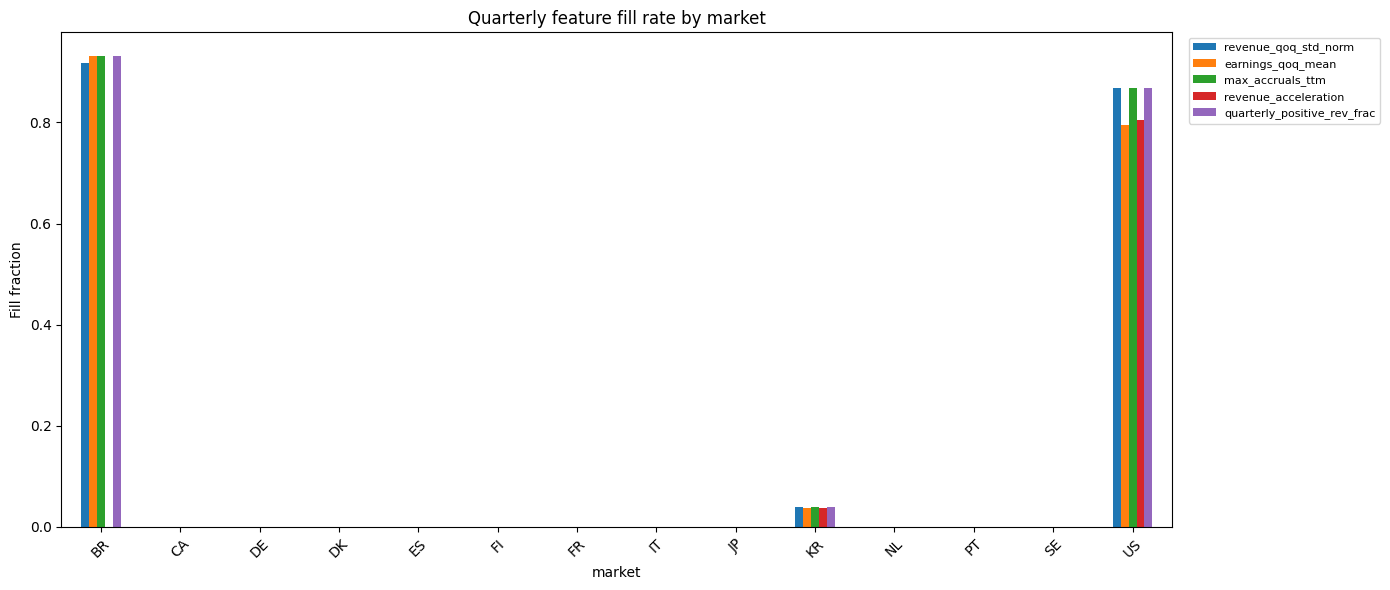

In [4]:
qcols_present = [c for c in QUARTERLY_COLS if c in annual.columns]
if qcols_present and 'market' in annual.columns:
    cov = annual.groupby('market')[qcols_present].apply(lambda g: g.notna().mean())
    print('Quarterly feature fill rate by market:')
    print(cov.to_string())
    
    fig, ax = plt.subplots(figsize=(14, 6))
    cov.plot(kind='bar', ax=ax)
    ax.set_title('Quarterly feature fill rate by market')
    ax.set_ylabel('Fill fraction')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

## 4 — Column count verification

In [5]:
expected_cols = 341
actual = df_clean.shape[1]
status = '✅' if actual == expected_cols else '❌'
print(f'{status} Column count: {actual} (expected {expected_cols})')

# Check expected column groups
groups = {
    'ML scores': [c for c in df_clean.columns if c.startswith('ml_')],
    'Alpha scores': [c for c in df_clean.columns if c.startswith('alpha_')],
    'Quarterly cols': [c for c in df_clean.columns if c in QUARTERLY_COLS],
    'Imputation flags': [c for c in df_clean.columns if c.endswith('_imputed')],
}
for name, cols in groups.items():
    print(f'  {name}: {len(cols)} — {cols}')

❌ Column count: 346 (expected 341)
  ML scores: 3 — ['ml_1y', 'ml_3y', 'ml_5y']
  Alpha scores: 6 — ['alpha_value', 'alpha_quality', 'alpha_momentum', 'alpha_growth', 'alpha_fraud_risk', 'alpha_composite']
  Quarterly cols: 5 — ['revenue_qoq_std_norm', 'earnings_qoq_mean', 'max_accruals_ttm', 'revenue_acceleration', 'quarterly_positive_rev_frac']
  Imputation flags: 1 — ['size_category_imputed']


## 5 — Quarterly feature distributions (violin)

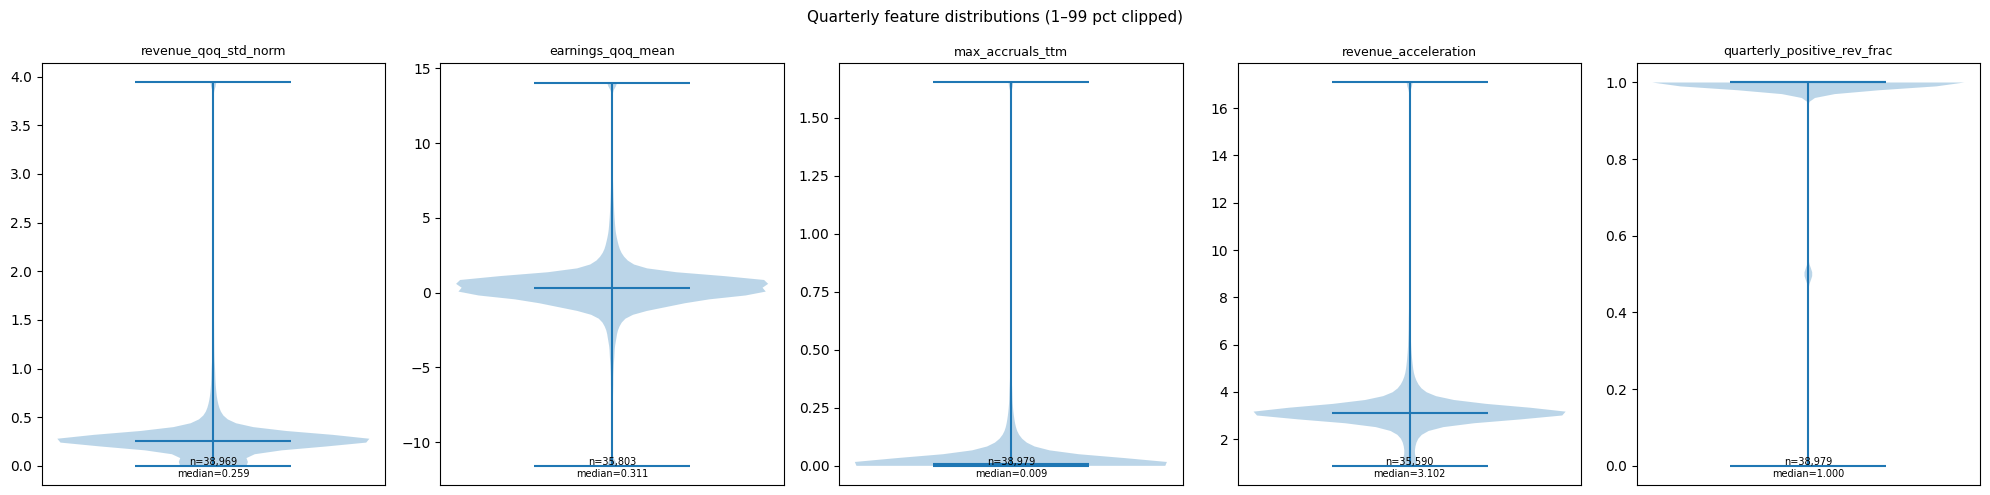

In [6]:
qcols_present = [c for c in QUARTERLY_COLS if c in annual.columns]
if qcols_present:
    fig, axes = plt.subplots(1, len(qcols_present), figsize=(4 * len(qcols_present), 5))
    if len(qcols_present) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, qcols_present):
        s = annual[col].dropna()
        p01, p99 = s.quantile(0.01), s.quantile(0.99)
        s_clipped = s.clip(p01, p99)
        ax.violinplot(s_clipped, showmedians=True)
        ax.set_title(col, fontsize=9)
        ax.set_xticks([])
        ax.text(0.5, 0.02, f'n={len(s):,}\nmedian={s.median():.3f}',
                transform=ax.transAxes, ha='center', fontsize=7)
    
    plt.suptitle('Quarterly feature distributions (1–99 pct clipped)', fontsize=11)
    plt.tight_layout()
    plt.show()